In [102]:
from math import pi
from typing import Union, overload
import numpy as np
from daceypy import DA, array
from daceypy.op import cos, sin, sqrt  # can be used on DA and on floats
from inspect import getsourcefile
from pathlib import Path
import matplotlib.pyplot as plt
sourcefile = getsourcefile(lambda: 0)
assert sourcefile is not None
thisfolder = Path(sourcefile).resolve().parent

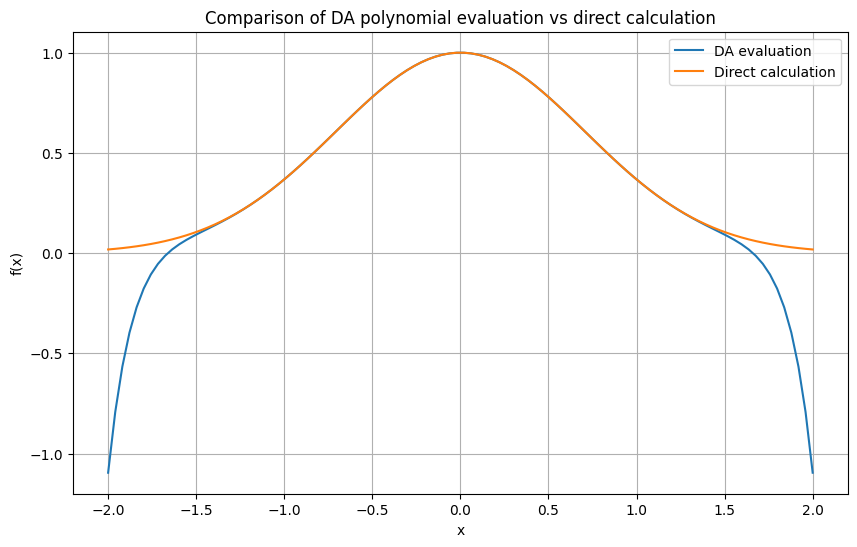

In [103]:
DA.init(15,1)

N = 100          #grid of points
x0 = 0
x = x0 + DA(1)    #DA number
f = (-x**2).exp() #DA function
hw = 2.0         #length of grid from

x_points = []
rda_points = []
rdouble_points = []

i = 0

for i in range(N):
    xx = -hw + i * 2 * hw / (N - 1)               # point on the grid [-hw,hw] - creates evenly spaced point within [-hw,hw] grid
    # note: not an efficient way
    rda = f.evalScalar(xx)  #evaluate point xx on the polynomial map
    xx += x0
    rdouble = np.exp(-xx * xx)
    x_points.append(xx)
    rda_points.append(rda)
    rdouble_points.append(rdouble)

plt.figure(figsize=(10, 6))
plt.plot(x_points, rda_points, label='DA evaluation')
plt.plot(x_points, rdouble_points, label='Direct calculation')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Comparison of DA polynomial evaluation vs direct calculation')
plt.legend()
plt.grid(True)
plt.show()

C:\Users\chezh\AppData\Local\Temp\ipykernel_3200\761017158.py:10: RuntimeWarning: invalid value encountered in scalar divide
  f = sin(norm) / norm


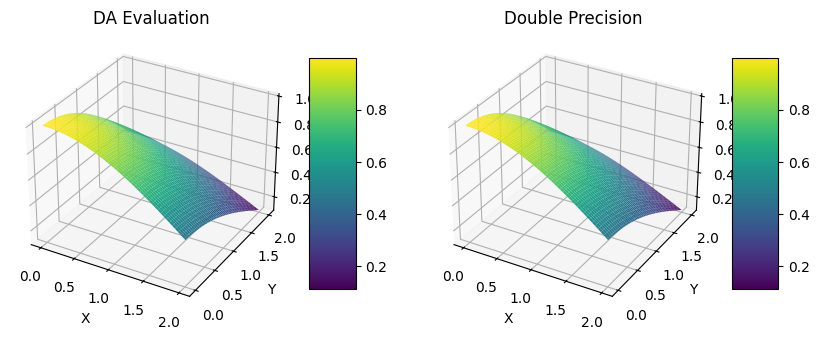

In [104]:
#Ex 2.2
def somb(x: DA, y: DA) -> DA:
    norm = (x**2 + y**2).sqrt()
    f = norm.sin() / norm
    return f

def somb_float(x: float, y: float) -> float:
    norm = sqrt(x**2 + y**2)
    try:
        f = sin(norm) / norm
        return f
    except ZeroDivisionError:
        return float("nan")

DA.init(10,2)
N = 100                 #grid points

hw = 1.0                #grid length [-1,1]
x0 = 1
y0 = 1
x = x0 + DA(1)
y = y0 + DA(2)
f = somb(x, y)

i = 0

x_points = []
y_points = []
rda_points = []
rdouble_points = []
arg = np.zeros(2)
for i in range(N):
    # x components in grid
    for j in range(N):
        arg[0] = -hw + i * 2 * hw / (N - 1)         #get the x coordinate point
        arg[1] = -hw + j * 2 * hw / (N - 1)         #get the y coordinate point
        rda = f.eval(arg)                           #evaluate the [x,y] coordinates within the DA polynomial. arg[0] = DA(1)                                                arg[1] = DA(2)

        rdouble = somb_float(x0 + arg[0], y0 + arg[1])   #evaluate x0 and subtract/add the step, do the same for y0

        x_points.append(x0 + arg[0])
        y_points.append(y0 + arg[1])
        rda_points.append(rda)
        rdouble_points.append(rdouble)


#reshape the data for plot
X = np.array(x_points).reshape(N, N)
Y = np.array(y_points).reshape(N, N)
rda_points = np.array(rda_points).reshape(N, N)                     #We can do this becuase evaluating the DA map returns a float
rdouble_points = np.array(rdouble_points).reshape(N, N)


#create 3D plot
fig = plt.figure(figsize=(10, 6))
#DA plot
ax1 = fig.add_subplot(121, projection='3d')
surf1 = ax1.plot_surface(X, Y, rda_points, cmap='viridis', edgecolor='none')
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_zlabel('f(x,y)')
ax1.set_title('DA Evaluation')
fig.colorbar(surf1, ax=ax1, shrink=0.5, aspect=5)

#Plot double precision
ax2 = fig.add_subplot(122, projection='3d')
surf2 = ax2.plot_surface(X, Y, rdouble_points, cmap='viridis', edgecolor='none')
ax2.set_xlabel('X')
ax2.set_ylabel('Y')
ax2.set_zlabel('f(x,y)')
ax2.set_title('Double Precision')
fig.colorbar(surf2, ax=ax2, shrink=0.5, aspect=5)


In [105]:
#Ex 2.3


DA.pushTO(10)
x = DA(1)
g = x.sin()

f_direct = (x+2).sin()
f_eval = g.evalScalar(x + 2)

DA.popTO()

print(f"DA direct:\n{f_direct}")
print(f"DA eval:\n{f_eval}")

DA direct:
     I  COEFFICIENT              ORDER EXPONENTS
     1    9.0929742682568171e-01   0   0  0
     2   -4.1614683654714241e-01   1   1  0
     3   -4.5464871341284085e-01   2   2  0
     4    6.9357806091190397e-02   3   3  0
     5    3.7887392784403402e-02   4   4  0
     6   -3.4678903045595199e-03   5   5  0
     7   -1.2629130928134467e-03   6   6  0
     8    8.2568816775226663e-05   7   7  0
     9    2.2552019514525833e-05   8   8  0
    10   -1.1467891218781481e-06   9   9  0
    11   -2.5057799460584258e-07  10  10  0
------------------------------------------------
DA eval:
     I  COEFFICIENT              ORDER EXPONENTS
     1    9.0934744268077605e-01   0   0  0
     2   -4.1587301587301595e-01   1   1  0
     3   -4.5396825396825397e-01   2   2  0
     4    7.0370370370370361e-02   3   3  0
     5    3.8888888888888890e-02   4   4  0
     6   -2.7777777777777775e-03   5   5  0
     7   -9.2592592592592596e-04   6   6  0
     8    1.9841269841269841e-04   7   7 

Text(0.5, 1.0, 'Error in DA evaluation of erf')

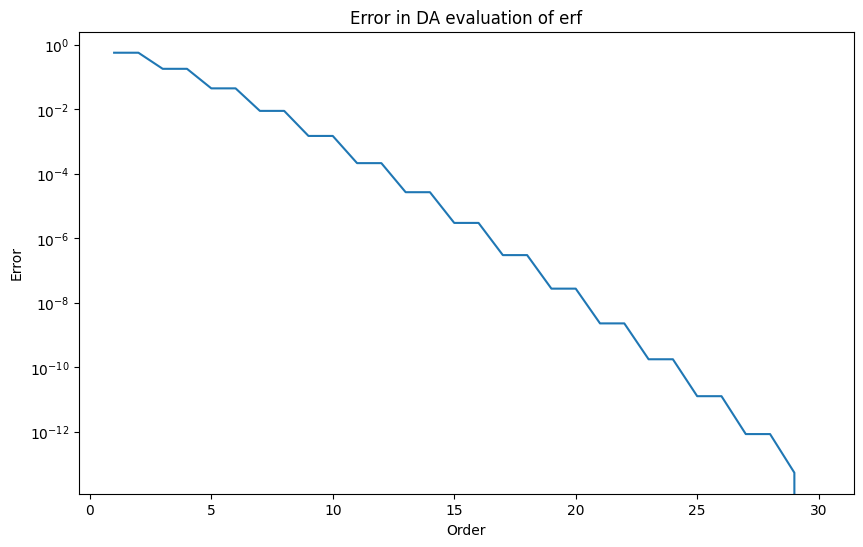

In [106]:
#ex3.4 Error evaluation of a function
def erf(x: DA) -> float:
    I = (2 / sqrt(pi)) * (-x.sqr()).exp().integ(1)                #Obtain the coefficents of the erf integral
    f = I.evalScalar(1) - I.evalScalar(-1)              #Evaluate the integral at bounds
    return f

order = 30
DA.init(order,1)

i = 0
err = np.zeros(order)                   #initialse error array
corr = 1.685401585899429                #floating point evaluated answer

for i in range(1,order):
    DA.pushTO(i)
    x = DA(1)
    f = erf(x)
    err[i-1] = abs(f-corr)
    DA.popTO()

#Plot DA evaluation error for integration with respect to order
order_array = np.linspace(1,order,order)
plt.figure(figsize=(10, 6))
plt.plot(order_array, err, label='DA evaluation Error')
plt.yscale('log')
plt.xlabel('Order')
plt.ylabel('Error')
plt.title('Error in DA evaluation of erf')




Single precision Error: 0.0014954176076453773


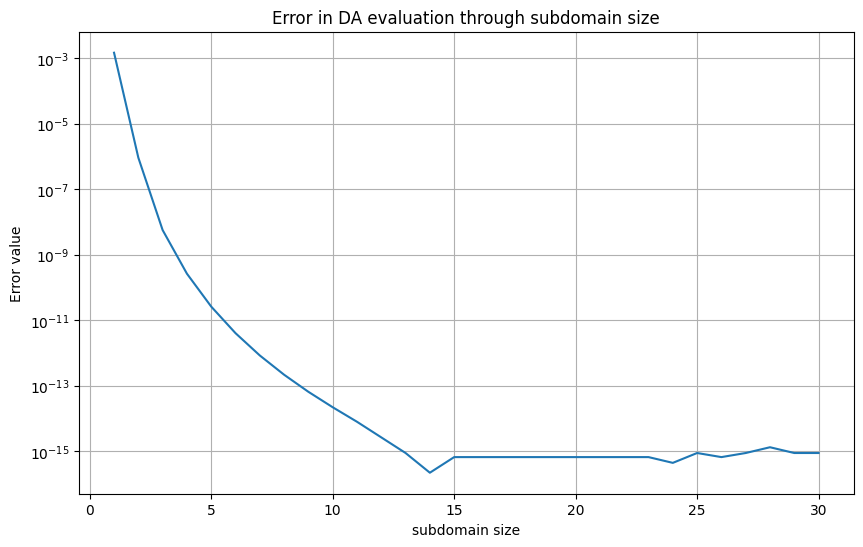

In [107]:
#Ex 3.2.1 Domain splitting and error relationship
def erf(a: float, b: float) -> float:
    x = ((a + b) / 2.0) + DA(1)                             #Centre point of the subdomain in DA
    I = (2.0 / sqrt(pi)) * (-x.sqr()).exp().integ(1)                #Obtain the coefficents of the erf integral
    f = I.evalScalar((b-a)/2) - I.evalScalar(-(b-a)/2)              #Evaluate the integral at bounds
    return f

DA.pushTO(9)

corr = 1.685401585899429                        #floating point evaluated answer
hw = 1                                          #set domain[-1,1]
err = np.zeros(30)                              #error array
for n in range(1,31):                           #vary subdomain size from 1 to 30
    f = 0.0
    for i in range(1,n+1):
        a = -hw + (i - 1) * 2 * hw/n                 #Lower bound of the subdomain
        a_1 = -hw + i * 2 *hw/n                     #Upper bound of the subdomain
        f += erf(a, a_1)                        #summate the taylor expansion around centre  point of subdomain
    err[n-1] = abs(f - corr)           #calculate error

N = np.linspace(1, 30, 30)
single = erf(-hw, hw)
print(f"Single precision Error: {abs(single - corr)}")
#Plot Error vs subdomain size

plt.figure(figsize=(10, 6))
plt.plot(N,err, label='Error in DA evaluation through subdomain size')
plt.yscale('log')
plt.xlabel('subdomain size')
plt.ylabel('Error value')
plt.title('Error in DA evaluation through subdomain size')
plt.grid(True)




Why does the error reduce quicker in subdomain splitting over order increase?